# Kepler-51: análisis del **photo-eccentric effect (PE)** con *asterodensity profiling*

Este notebook implementa, para los planetas transiting del sistema **Kepler-51**, el análisis del **photo-eccentric effect** descrito en:

- Kipping (2014), *MNRAS* **440**, 2164 — *Characterizing distant worlds with asterodensity profiling*.

**Fuentes de parámetros del sistema**  
Los valores (estrella + planetas) se copiaron manualmente desde el *NASA Exoplanet Archive* (página “overview” de Kepler-51) en la fecha **2026-02-23**.  
- Kepler-51 (host): masa, radio, densidad estelar.  
- Kepler-51 b/c/d: periodo, $R_p/R_\star$, $T_{14}$, $a/R_\star$ y parámetro de impacto $b$.  
- Kepler-51 e: en la vista usada aparece principalmente como detección por TTV; no aporta (en el extracto) los parámetros de tránsito necesarios para PE.

**Paquete requerido**: `geotrans2.py` (GeoTrans) adjunto, usado para la geometría/astrofísica del tránsito.


## Referencias y enlaces

- NASA Exoplanet Archive — Kepler-51 overview (parámetros estelares y planetarios): https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51  
- Kipping, D. (2014), *MNRAS* 440, 2164 — *Characterizing distant worlds with asterodensity profiling*: https://academic.oup.com/mnras/article/440/3/2164/1075072  

(En este notebook, los valores numéricos se copiaron desde el overview del Archive en 2026-02-23.)


In [2]:
# --- Setup ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geotrans2 import (
    RingedSystem, contactTimes, rhoObserved_Kipping,
    RSUN, MSUN, GCONST, HOUR, DAY, DEG
)

from math import pi

PI = pi

print("GeoTrans importado correctamente.")


GeoTrans importado correctamente.


## 1. Parámetros del sistema (inputs)

> Nota: estos valores se copiaron desde el *NASA Exoplanet Archive* (overview de Kepler-51).  
> Luego verificamos consistencia básica (si $a/R_\star$ y $b$ reproducen un $T_{14}$ similar).

Citas (overview de Kepler-51):
- Radio estelar $R_\star$, masa estelar $M_\star$ y densidad estelar $\rho_\star$ aparecen en la tabla de “Stellar Parameters”.  
- Para cada planeta b/c/d, $P$, $R_p/R_\star$, $T_{14}$, $a/R_\star$ y $b$ aparecen en su tabla de “Planetary Parameters”.


In [3]:
star_params = {
  "st_mass_msun": 0.985,
  "st_mass_err": 0.012,
  "st_rad_rsun": 0.881,
  "st_rad_err": 0.011,
  "st_dens_gcm3": 2.03,
  "st_dens_err": 0.08
}
planets = {
  "Kepler-51 b": {
    "P_days": 45.155279,
    "RpRs": 0.07221,
    "T14_hr": 5.754,
    "aRs": 62.81,
    "b": 0.192
  },
  "Kepler-51 c": {
    "P_days": 85.312,
    "RpRs": 0.0629,
    "T14_hr": 2.702,
    "aRs": 96.0,
    "b": 0.9788
  },
  "Kepler-51 d": {
    "P_days": 130.189,
    "RpRs": 0.09837,
    "T14_hr": 8.402,
    "aRs": 127.23,
    "b": 0.183
  },
  "Kepler-51 e": {
    "P_days": 264.284
  }
}

Mstar = star_params["st_mass_msun"] * MSUN
Rstar = star_params["st_rad_rsun"]  * RSUN

rho_star_true = Mstar / (4/3 * PI * Rstar**3)     # kg/m^3
rho_star_true_gcm3 = rho_star_true / 1000.0       # g/cm^3

print(f"Rstar = {star_params['st_rad_rsun']:.3f} R_sun")
print(f"Mstar = {star_params['st_mass_msun']:.3f} M_sun")
print(f"rho_star_true = {rho_star_true_gcm3:.3f} g/cm^3 (por M/R^3)")
print(f"rho_star_archive = {star_params['st_dens_gcm3']:.3f} g/cm^3 (tabla)")


Rstar = 0.881 R_sun
Mstar = 0.985 M_sun
rho_star_true = 2.025 g/cm^3 (por M/R^3)
rho_star_archive = 2.030 g/cm^3 (tabla)


\
## 2. Marco teórico mínimo del Photo-Eccentric Effect (PE)

En **asterodensity profiling**, se compara:

- **Densidad estelar verdadera**: $\rho_\star$ (independiente del tránsito).
- **Densidad estelar “inferida del tránsito” bajo circularidad**: $\rho_{\star,\mathrm{circ}}$ (o $\rho_\mathrm{obs}$).

Si el planeta realmente transita en una órbita excéntrica $(e,\omega)$, entonces:

$$
\frac{\rho_{\star,\mathrm{circ}}}{\rho_\star}
=
\left(
\frac{1 + e\sin\omega}{\sqrt{1-e^2}}
\right)^3
\equiv \Psi^3
$$

donde:

$$
\Psi = \frac{1 + e\sin\omega}{\sqrt{1-e^2}}.
$$

En la práctica:

1) A partir de parámetros de tránsito se estima $\rho_{\star,\mathrm{circ}}$.  
2) Se compara con $\rho_\star$.  
3) La discrepancia constriñe $(e,\omega)$.

Cita principal: Kipping (2014), *MNRAS* 440, 2164.


In [4]:
# --- Helpers del PE ---

def e_min_from_ratio(ratio: float) -> float:
    '''
    Eccentricidad mínima e_min compatible con un cociente R = rho_circ/rho_true,
    al permitir el valor 'óptimo' de omega (sin(omega)=+1 para R>1, sin(omega)=-1 para R<1).

    Partimos de:
      R = ((1 + e sin ω)/sqrt(1-e^2))^3

    Definimos Psi = R^(1/3) y resolvemos:
      Psi = (1 ± e)/sqrt(1-e^2)

    Resultado:
      e_min = |Psi^2 - 1| / (Psi^2 + 1)
    '''
    if ratio <= 0:
        return np.nan
    Psi = ratio**(1/3)
    e = abs(Psi**2 - 1) / (Psi**2 + 1)
    return float(e)

def build_ringless_system_from_transit(RpRs, aRs, b, Mstar, Rstar):
    '''
    Construye un RingedSystem (sin anillos) con órbita circular (e=0),
    usando (Rp/Rs, a/Rs, b) como entradas.

    - ap se fija con a/Rs * Rstar.
    - iorb se fija usando b ≈ (a/Rs) cos(i) para e=0.
    - wp se fija 0 (en e=0 es irrelevante).
    '''
    S = RingedSystem()
    S.noauto = True

    # Star
    S.Mstar = Mstar
    S.Rstar = Rstar

    # Orbit
    S.ap = aRs * Rstar
    S.ep = 0.0
    S.wp = 0.0

    # Inclination from b ≈ (a/Rs) cos(i)
    cosi = np.clip(b / aRs, -1, 1)
    S.iorb = np.arccos(cosi)

    # Planet
    S.Rplanet = RpRs * Rstar
    S.Mplanet = 0.0

    # Ringless
    S.tau = 0.0
    S.fe  = 0.0
    S.fi  = 0.0

    S.noauto = False
    S.updateSystem()
    return S


## 3. Cálculo de $\rho_{\star,\mathrm{circ}}$ con GeoTrans

GeoTrans ofrece `rhoObserved_Kipping(p, Rstar, tT, tF, P)`, donde:

- $p = (R_p/R_\star)^2$ (profundidad geométrica).
- $t_T = T_{14}$ (primer a cuarto contacto).
- $t_F = T_{23}$ (segundo a tercer contacto).
- $P$ es el periodo.

**Estrategia**:

1) Construimos un sistema circular ringless con `RingedSystem`.  
2) Con `contactTimes(S)` obtenemos $t_1,t_2,t_3,t_4$ y derivamos $t_T$ y $t_F$.  
3) Con esos tiempos y $P$ calculamos $\rho_{\star,\mathrm{circ}}$.  
4) Comparamos contra $\rho_\star$ y estimamos $e_{\min}$.


In [7]:
results = []

for pl_name, d in planets.items():
    required = {"P_days", "RpRs", "aRs", "b", "T14_hr"}
    if not required.issubset(d.keys()):
        print(f"[INFO] {pl_name}: faltan parámetros de tránsito (se omite PE).")
        continue

    P_days = d["P_days"]
    RpRs   = d["RpRs"]
    aRs    = d["aRs"]
    b      = d["b"]
    T14_hr_archive = d["T14_hr"]

    S = build_ringless_system_from_transit(RpRs, aRs, b, Mstar, Rstar)

    S.tcen, t1, t2, t3, t4 = contactTimes(S)
    tT = (t4 - t1)                 # seconds
    tF = (t3 - t2)                 # seconds

    p_depth = RpRs**2
    P_sec = P_days * DAY

    rho_obs = rhoObserved_Kipping(p_depth, Rstar, tT, tF, P_sec)  # kg/m^3
    rho_obs_gcm3 = rho_obs / 1000.0

    ratio = rho_obs / rho_star_true
    e_min = e_min_from_ratio(ratio)

    results.append({
        "planet": pl_name,
        "P_days": P_days,
        "RpRs": RpRs,
        "aRs": aRs,
        "b": b,
        "T14_hr_archive": T14_hr_archive,
        "T14_hr_model": tT / HOUR,
        "T23_hr_model": tF / HOUR,
        "rho_star_true_gcm3": rho_star_true_gcm3,
        "rho_circ_gcm3": rho_obs_gcm3,
        "rho_ratio": ratio,
        "e_min": e_min,
        "Porb_model_days_from_Mstar_aRs": S.Porb / DAY
    })

df = pd.DataFrame(results)
df


[INFO] Kepler-51 e: faltan parámetros de tránsito (se omite PE).


,planet,P_days,RpRs,aRs,b,T14_hr_archive,T14_hr_model,T23_hr_model,rho_star_true_gcm3,rho_circ_gcm3,rho_ratio,e_min,Porb_model_days_from_Mstar_aRs
0,Kepler-51 b,45.155279,0.07221,62.81,0.1920,5.754,6.172706,5.311446,2.025297,1.466863e-07,7.242707e-08,0.999965,48.108058
1,Kepler-51 c,85.312000,0.06290,96.00,0.9788,2.702,2.997709,0.000000,2.025297,2.601221e-07,1.284365e-07,0.999949,90.903685
2,Kepler-51 d,130.189000,0.09837,127.23,0.1830,8.402,9.019284,7.352384,2.025297,1.466907e-07,7.242926e-08,0.999965,138.694401


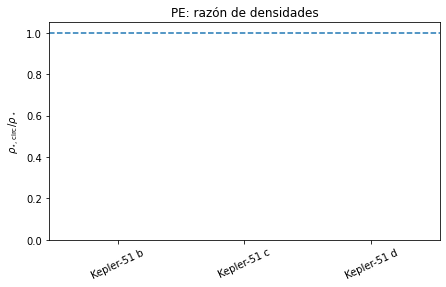

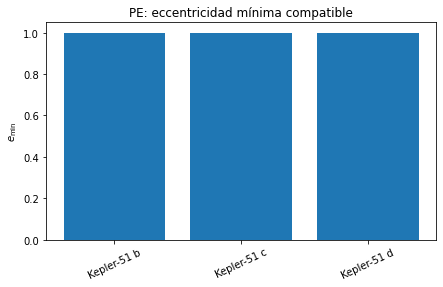

In [8]:
# Plots rápidos
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(df["planet"], df["rho_ratio"])
    ax.axhline(1.0, linestyle="--")
    ax.set_ylabel(r"$\rho_{\star,\mathrm{circ}}/\rho_\star$")
    ax.set_title("PE: razón de densidades")
    ax.tick_params(axis='x', rotation=25)
    plt.show()

    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(df["planet"], df["e_min"])
    ax.set_ylabel(r"$e_{\min}$")
    ax.set_title("PE: eccentricidad mínima compatible")
    ax.tick_params(axis='x', rotation=25)
    plt.show()


\
## 4. Región $(e,\omega)$ compatible con cada cociente de densidades

De:

\[
R^{1/3} = \frac{1 + e\sin\omega}{\sqrt{1-e^2}}
\]

para un $e$ dado, se puede inferir:

\[
\sin\omega = \frac{R^{1/3}\sqrt{1-e^2}-1}{e}
\]

y exigir $|\sin\omega|\le 1$.

A continuación se dibuja un mapa binario de viabilidad (True/False) en el plano $(\omega,e)$.


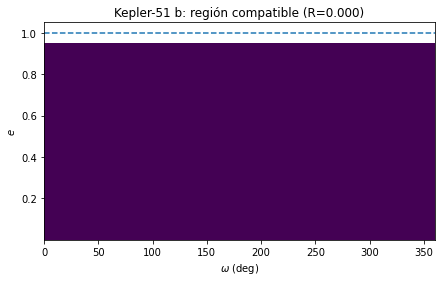

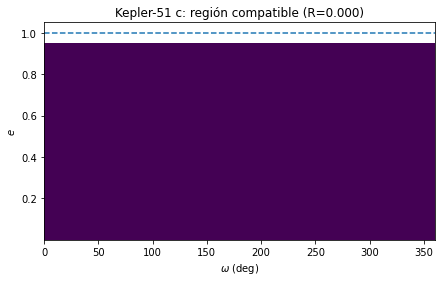

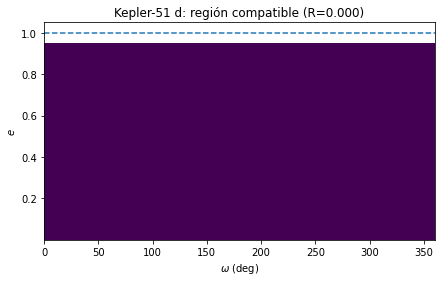

In [9]:
def omega_feasible_region(ratio, e_grid=None, omega_grid_deg=None):
    if e_grid is None:
        e_grid = np.linspace(1e-4, 0.95, 600)
    if omega_grid_deg is None:
        omega_grid_deg = np.linspace(0, 360, 721)

    E, W = np.meshgrid(e_grid, np.deg2rad(omega_grid_deg), indexing="xy")
    Psi = ratio**(1/3)
    sinw = (Psi*np.sqrt(1-E**2) - 1)/E
    feasible = np.abs(sinw) <= 1
    return e_grid, omega_grid_deg, feasible

for _, row in df.iterrows():
    ratio = row["rho_ratio"]
    e_grid, w_deg, feas = omega_feasible_region(ratio)

    fig, ax = plt.subplots(figsize=(7,4))
    ax.imshow(feas.T, origin="lower", aspect="auto",
              extent=[w_deg.min(), w_deg.max(), e_grid.min(), e_grid.max()])
    ax.set_xlabel(r"$\omega$ (deg)")
    ax.set_ylabel(r"$e$")
    ax.set_title(f"{row['planet']}: región compatible (R={ratio:.3f})")
    ax.axhline(row["e_min"], linestyle="--")
    plt.show()


## 5. Exportar resultados (CSV) para Notion

In [ ]:
out_csv = "kepler51_photoeccentric_results.csv"
df.to_csv(out_csv, index=False)
print(f"CSV guardado en: {out_csv}")
